# Pipeline C — Ensemble of Pipeline A and Pipeline B

Per [Aug_24_Plan.md](../progress/Aug_24_Plan.md)'s next steps and KNOWLEDGE.md §5.1
("ensembling is nearly free accuracy"): both Pipeline A (flat LightGBM) and Pipeline B
(two-stage ETS + LightGBM offset) already beat the naive and linear baselines individually,
and Pipeline B beats Pipeline A outright on the untouched holdout ($105.79 vs $128.09 MAE).
This notebook checks whether blending their dollar-space predictions — no new model, just a
weighted average of two already-trained models' outputs — improves on Pipeline B alone.

**Approach**: `predicted_rate = w x pipeline_A_pred + (1-w) x pipeline_B_pred`. `w` is picked
by grid search on the same 3 expanding-window CV folds (minimizing mean CV MAE), then applied
once to the untouched Sep-Oct holdout — same discipline as every other hyperparameter choice
in this project. Both components reuse their established configs verbatim (Pipeline A's
`k_lane=60, k_city=15` shrinkage encoder + monotone-constrained LightGBM; Pipeline B's ETS
Stage 1 winner + unconstrained Stage 2 LightGBM) rather than re-tuning either — this notebook
is purely about the blend weight.

In [1]:
import warnings

import lightgbm as lgb
from lightgbm.basic import LGBMDeprecationWarning
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from data import ExpandingWindowCVConfig, ExpandingWindowCVSplitter, load_data
from eval import mae, rmse, smape

warnings.filterwarnings("ignore", category=LGBMDeprecationWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 0

## 1. Load & clean

Same as both pipelines: `weight = weight.abs()` (sign-flip bug), plus the `market_missing`
flag Pipeline A's component needs for its market-feature block.

In [2]:
raw = load_data()
raw["date"] = pd.to_datetime(raw["date"])

clean = raw.copy()
clean["weight"] = clean["weight"].abs()
clean["market_missing"] = clean["market_index"].isna().astype(int)

print(f"raw: {raw.shape}")
print(f"negative-weight rows fixed: {(raw['weight'] < 0).sum()}")

raw: (48000, 14)
negative-weight rows fixed: 292


## 2. Shared feature engineering

Geo/date features and the shrinkage lane encoder are identical between Pipeline A and B, so
they're fit **once** here and shared — `build_features` returns full-column frames; each
component then selects its own feature subset (Pipeline A adds the market columns and its
own target; Pipeline B does not, and computes its offset target separately in §4/§6, since
that depends on the daily market-level forecast).

In [3]:
def haversine_miles(lat1, lon1, lat2, lon2):
    r = 3958.8
    la1, lo1, la2, lo2 = map(np.radians, [lat1, lon1, lat2, lon2])
    return 2 * r * np.arcsin(
        np.sqrt(np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2)
    )


def add_shipment_geo_date_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["log_distance"] = np.log1p(out["distance"])
    out["haversine"] = haversine_miles(out["pickup_lat"], out["pickup_lon"], out["delivery_lat"], out["delivery_lon"])
    out["circuity"] = out["distance"] / out["haversine"]
    out["lon_delta"] = out["delivery_lon"] - out["pickup_lon"]

    doy = out["date"].dt.dayofyear
    dow = out["date"].dt.dayofweek
    out["month_sin"] = np.sin(2 * np.pi * out["date"].dt.month / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["date"].dt.month / 12)
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365)
    out["is_weekend"] = (dow >= 5).astype(int)
    out["days_since_start"] = (out["date"] - pd.Timestamp("2025-01-01")).dt.days

    christmas = pd.Timestamp("2025-12-25")
    new_year = pd.Timestamp("2026-01-01")
    out["days_to_christmas"] = (christmas - out["date"]).dt.days
    out["days_to_new_year"] = (new_year - out["date"]).dt.days

    out["equipment"] = out["equipment"].astype("category")
    return out

In [4]:
def fit_lane_target_encoder_shrink(train_df: pd.DataFrame, target: pd.Series, k_lane: float, k_city: float) -> dict:
    """Count-weighted empirical-Bayes shrinkage lane encoder (pipeline_a.ipynb, Aug 24 fix)."""
    y = target.reindex(train_df.index)
    global_mean = y.mean()

    pickup_stats = y.groupby(train_df["pickup"]).agg(["mean", "count"])
    delivery_stats = y.groupby(train_df["delivery"]).agg(["mean", "count"])
    pickup_shrunk = (pickup_stats["count"] * pickup_stats["mean"] + k_city * global_mean) / (pickup_stats["count"] + k_city)
    delivery_shrunk = (delivery_stats["count"] * delivery_stats["mean"] + k_city * global_mean) / (delivery_stats["count"] + k_city)

    lane_stats = y.groupby([train_df["pickup"], train_df["delivery"]]).agg(["mean", "count"])
    return {
        "lane_mean": lane_stats["mean"],
        "lane_count": lane_stats["count"],
        "pickup_shrunk": pickup_shrunk,
        "delivery_shrunk": delivery_shrunk,
        "global": global_mean,
        "k_lane": k_lane,
    }


def apply_lane_target_encoder_shrink(df: pd.DataFrame, encoder: dict) -> pd.Series:
    global_mean, k_lane = encoder["global"], encoder["k_lane"]
    pu = encoder["pickup_shrunk"].reindex(df["pickup"]).to_numpy()
    de = encoder["delivery_shrunk"].reindex(df["delivery"]).to_numpy()
    pu = np.where(np.isnan(pu), global_mean, pu)
    de = np.where(np.isnan(de), global_mean, de)
    city_prior = (pu + de) / 2.0

    lane_idx = pd.MultiIndex.from_arrays([df["pickup"], df["delivery"]])
    lane_mean = np.nan_to_num(encoder["lane_mean"].reindex(lane_idx).to_numpy(), nan=0.0)
    lane_count = np.nan_to_num(encoder["lane_count"].reindex(lane_idx).to_numpy(), nan=0.0)

    enc = (lane_count * lane_mean + k_lane * city_prior) / (lane_count + k_lane)
    return pd.Series(enc, index=df.index, name="lane_target_enc")


K_LANE, K_CITY = 60, 15  # selected by pipeline_a.ipynb §3b's CV grid search

In [5]:
NUMERIC_BASE = [
    "distance", "log_distance", "weight", "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon",
    "circuity", "lon_delta", "month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos",
    "is_weekend", "days_since_start", "days_to_christmas", "days_to_new_year", "lane_target_enc",
]
MARKET_FEATURES = ["market_index", "quote_signal", "market_missing"]
CATEGORICAL = ["equipment"]

A_FEATURE_COLS = NUMERIC_BASE + CATEGORICAL + MARKET_FEATURES  # Pipeline A: use_market=True (Aug 22 finding)
B_FEATURE_COLS = NUMERIC_BASE + CATEGORICAL  # Pipeline B: no market features (see intro)


def build_features(train_raw: pd.DataFrame, apply_raw: pd.DataFrame):
    """Fit geo/date features + the shrinkage lane encoder on train_raw only, apply to both.
    Returns full-column (train_feat, apply_feat) -- callers select A_FEATURE_COLS/B_FEATURE_COLS.
    """
    train_feat = add_shipment_geo_date_features(train_raw)
    apply_feat = add_shipment_geo_date_features(apply_raw)

    y_train_log = np.log1p(train_raw["posted_rate"])
    enc = fit_lane_target_encoder_shrink(train_feat, y_train_log, k_lane=K_LANE, k_city=K_CITY)
    train_feat["lane_target_enc"] = apply_lane_target_encoder_shrink(train_feat, enc)
    apply_feat["lane_target_enc"] = apply_lane_target_encoder_shrink(apply_feat, enc)
    return train_feat, apply_feat

## 3. Component A — flat LightGBM (Pipeline A's Aug 24 config)

Target `log1p(posted_rate)`, monotone-constrained on `distance`/`log_distance` (they carry
~94% of the raw log-rate signal, EDA §10), `learning_rate=0.02`, `num_leaves=7`,
early-stopping patience 300 — identical to `pipeline_a.ipynb`.

In [6]:
LGB_PARAMS_A = dict(
    objective="regression",
    metric="rmse",
    learning_rate=0.02,
    num_leaves=7,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=3000,
    random_state=RANDOM_STATE,
    verbose=-1,
)
EARLY_STOPPING_PATIENCE = 300
MONOTONE_UP = ("distance", "log_distance")


def monotone_constraints_for(feature_cols):
    return [1 if c in MONOTONE_UP else 0 for c in feature_cols]


def fit_lgb_a(X_train, y_train, X_val, y_val, feature_cols, n_estimators=None):
    params = dict(LGB_PARAMS_A, monotone_constraints=monotone_constraints_for(feature_cols))
    if n_estimators is not None:
        params = dict(params, n_estimators=n_estimators)
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train, categorical_feature=CATEGORICAL)
        return model
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=CATEGORICAL,
        callbacks=[lgb.early_stopping(EARLY_STOPPING_PATIENCE, verbose=False)],
    )
    return model

## 4. Component B — two-stage (ETS + LightGBM offset)

Stage 1 uses **ETS (damped trend + weekly seasonal)** directly — `pipeline_b.ipynb` §3b
already backtested it against drift/SARIMA/seasonal-naive and it won; not re-run here, same
"reuse the established selection" choice Pipeline B made for Pipeline A's `k_lane`/`k_city`.
Stage 2: LightGBM on `log(posted_rate / (daily_level x distance))`, no monotone constraint
(distance's dominant effect is already divided out of this target).

In [7]:
def build_daily_index(df: pd.DataFrame) -> pd.DataFrame:
    rate_per_mile = df["posted_rate"] / df["distance"]
    daily = (
        df.assign(rate_per_mile=rate_per_mile)
        .groupby("date")
        .agg(rpm_median=("rate_per_mile", "median"), n=("rate_per_mile", "size"))
        .asfreq("D")
    )
    daily["rpm_median"] = daily["rpm_median"].interpolate(limit_direction="both")
    return daily


def ets_forecast(history: pd.Series, horizon: int) -> np.ndarray:
    model = ExponentialSmoothing(
        history, trend="add", damped_trend=True, seasonal="add", seasonal_periods=7,
        initialization_method="estimated",
    ).fit()
    return model.forecast(horizon).to_numpy()


LGB_PARAMS_B = dict(
    objective="regression",
    metric="rmse",
    learning_rate=0.02,
    num_leaves=7,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=3000,
    random_state=RANDOM_STATE,
    verbose=-1,
)


def fit_lgb_b(X_train, y_train, X_val, y_val, n_estimators=None):
    if n_estimators is not None:
        params = dict(LGB_PARAMS_B, n_estimators=n_estimators)
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train, categorical_feature=CATEGORICAL)
        return model
    model = lgb.LGBMRegressor(**LGB_PARAMS_B)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=CATEGORICAL,
        callbacks=[lgb.early_stopping(EARLY_STOPPING_PATIENCE, verbose=False)],
    )
    return model


def combine_predictions(offset_pred_log, daily_level, distance):
    return np.exp(offset_pred_log) * daily_level * distance

## 5. Shared evaluation harness

In [8]:
def naive_lane_rpm_predict(fold_train_raw, apply_raw):
    rpm = fold_train_raw["posted_rate"] / fold_train_raw["distance"]
    lane_rpm = rpm.groupby([fold_train_raw["pickup"], fold_train_raw["delivery"]]).median()
    global_rpm = rpm.median()
    idx = pd.MultiIndex.from_arrays([apply_raw["pickup"], apply_raw["delivery"]])
    pred_rpm = lane_rpm.reindex(idx).to_numpy()
    pred_rpm = np.where(np.isnan(pred_rpm), global_rpm, pred_rpm)
    return pred_rpm * apply_raw["distance"].to_numpy()


def score(y_true_rate, pred_rate, naive_pred_rate):
    naive_mae = mae(y_true_rate, naive_pred_rate)
    return {
        "MAE": mae(y_true_rate, pred_rate),
        "RMSE": rmse(y_true_rate, pred_rate),
        "SMAPE": smape(y_true_rate, pred_rate),
        "MASE": mae(y_true_rate, pred_rate) / naive_mae,
        "naive_MAE": naive_mae,
    }

## 6. CV: get A & B predictions per fold, grid-search the ensemble weight

Same 3 expanding-window folds as both pipelines. For each fold, fit both components and keep
their raw dollar-space predictions (not just the aggregate metric) so the blend weight can be
swept afterward without refitting anything.

In [9]:
splitter = ExpandingWindowCVSplitter(ExpandingWindowCVConfig())
result = splitter.split(clean)

fold_preds = {}
for fold in result.folds:
    train_feat, val_feat = build_features(fold.train, fold.val)

    # Component A
    X_tr_a, X_va_a = train_feat[A_FEATURE_COLS], val_feat[A_FEATURE_COLS]
    y_tr_a = np.log1p(fold.train["posted_rate"])
    y_va_a = np.log1p(fold.val["posted_rate"])
    model_a = fit_lgb_a(X_tr_a, y_tr_a, X_va_a, y_va_a, A_FEATURE_COLS)
    pred_a = np.expm1(model_a.predict(X_va_a, num_iteration=model_a.best_iteration_))

    # Component B
    daily_train = build_daily_index(fold.train)["rpm_median"]
    daily_val_actual = build_daily_index(fold.val)["rpm_median"]
    horizon = len(daily_val_actual)
    stage1_fc = pd.Series(ets_forecast(daily_train, horizon), index=daily_val_actual.index)

    X_tr_b, X_va_b = train_feat[B_FEATURE_COLS], val_feat[B_FEATURE_COLS]
    train_level = fold.train["date"].map(daily_train).to_numpy()
    val_level_actual = fold.val["date"].map(daily_val_actual).to_numpy()
    y_tr_b = np.log(fold.train["posted_rate"] / (train_level * fold.train["distance"].to_numpy()))
    y_va_b = np.log(fold.val["posted_rate"] / (val_level_actual * fold.val["distance"].to_numpy()))
    model_b = fit_lgb_b(X_tr_b, y_tr_b, X_va_b, y_va_b)
    offset_pred = model_b.predict(X_va_b, num_iteration=model_b.best_iteration_)
    val_level_forecast = fold.val["date"].map(stage1_fc).to_numpy()
    pred_b = combine_predictions(offset_pred, val_level_forecast, fold.val["distance"].to_numpy())

    naive_pred = naive_lane_rpm_predict(fold.train, fold.val)
    fold_preds[fold.index] = dict(
        y_true=fold.val["posted_rate"].to_numpy(), pred_a=pred_a, pred_b=pred_b, naive_pred=naive_pred,
    )
    print(f"fold {fold.index}: A best_iter={model_a.best_iteration_}, B best_iter={model_b.best_iteration_}")

fold 0: A best_iter=438, B best_iter=332


fold 1: A best_iter=509, B best_iter=265


fold 2: A best_iter=469, B best_iter=359


In [10]:
W_GRID = np.round(np.arange(0.0, 1.001, 0.05), 2)

grid_rows = []
for w in W_GRID:
    fold_maes = [
        mae(d["y_true"], w * d["pred_a"] + (1 - w) * d["pred_b"])
        for d in fold_preds.values()
    ]
    grid_rows.append({"w_a": w, "mean_MAE": np.mean(fold_maes)})

grid_df = pd.DataFrame(grid_rows).sort_values("mean_MAE").reset_index(drop=True)
print("ensemble weight grid (w_a=1.0 -> pure Pipeline A, w_a=0.0 -> pure Pipeline B):")
display(grid_df.round(3))

BEST_W = float(grid_df.iloc[0]["w_a"])
print(f"\nselected w_a={BEST_W} (weight on Pipeline A; Pipeline B gets {1 - BEST_W:.2f})")

ensemble weight grid (w_a=1.0 -> pure Pipeline A, w_a=0.0 -> pure Pipeline B):


,w_a,mean_MAE
0,0.80,137.178
1,0.75,137.243
2,0.85,137.299
3,0.70,137.474
4,0.90,137.631
5,0.65,137.835
6,0.95,138.193
7,0.60,138.315
8,0.55,138.918
9,1.00,139.014



selected w_a=0.8 (weight on Pipeline A; Pipeline B gets 0.20)


## 7. Final holdout evaluation (Sep-Oct, touched once)

Refit both components on the full Jan-Aug pool (each with its own early-stopping-tail
iteration count, same bug-fixed approach both notebooks use), blend with the CV-selected
`BEST_W`, evaluate once.

In [11]:
pool = clean[clean["date"] < "2025-09-01"]
holdout = result.holdout

es_tail_start = pool["date"].max() - pd.DateOffset(months=2) + pd.Timedelta(days=1)
es_fit = pool[pool["date"] < es_tail_start]
es_val = pool[pool["date"] >= es_tail_start]
print(f"early-stopping tail: fit on {len(es_fit)} rows (< {es_tail_start.date()}), "
      f"early-stop against {len(es_val)} rows (>= {es_tail_start.date()})")

es_fit_feat, es_val_feat = build_features(es_fit, es_val)
pool_feat, holdout_feat = build_features(pool, holdout)

# --- Component A final fit ---
Xes_a_fit, Xes_a_val = es_fit_feat[A_FEATURE_COLS], es_val_feat[A_FEATURE_COLS]
yes_a_fit = np.log1p(es_fit["posted_rate"])
yes_a_val = np.log1p(es_val["posted_rate"])
es_model_a = fit_lgb_a(Xes_a_fit, yes_a_fit, Xes_a_val, yes_a_val, A_FEATURE_COLS)
n_estimators_a = es_model_a.best_iteration_

X_pool_a, X_holdout_a = pool_feat[A_FEATURE_COLS], holdout_feat[A_FEATURE_COLS]
y_pool_a = np.log1p(pool["posted_rate"])
final_model_a = fit_lgb_a(X_pool_a, y_pool_a, None, None, A_FEATURE_COLS, n_estimators=n_estimators_a)
holdout_pred_a = np.expm1(final_model_a.predict(X_holdout_a))

# --- Component B final fit ---
daily_pool = build_daily_index(pool)["rpm_median"]
daily_holdout_index = build_daily_index(holdout).index
stage1_fc_holdout = pd.Series(ets_forecast(daily_pool, len(daily_holdout_index)), index=daily_holdout_index)

Xes_b_fit, Xes_b_val = es_fit_feat[B_FEATURE_COLS], es_val_feat[B_FEATURE_COLS]
es_fit_level = es_fit["date"].map(daily_pool).to_numpy()
es_val_level = es_val["date"].map(daily_pool).to_numpy()
yes_b_fit = np.log(es_fit["posted_rate"] / (es_fit_level * es_fit["distance"].to_numpy()))
yes_b_val = np.log(es_val["posted_rate"] / (es_val_level * es_val["distance"].to_numpy()))
es_model_b = fit_lgb_b(Xes_b_fit, yes_b_fit, Xes_b_val, yes_b_val)
n_estimators_b = es_model_b.best_iteration_

X_pool_b, X_holdout_b = pool_feat[B_FEATURE_COLS], holdout_feat[B_FEATURE_COLS]
pool_level = pool["date"].map(daily_pool).to_numpy()
y_pool_b = np.log(pool["posted_rate"] / (pool_level * pool["distance"].to_numpy()))
final_model_b = fit_lgb_b(X_pool_b, y_pool_b, None, None, n_estimators=n_estimators_b)
offset_pred_holdout = final_model_b.predict(X_holdout_b)
holdout_level_forecast = holdout["date"].map(stage1_fc_holdout).to_numpy()
holdout_pred_b = combine_predictions(offset_pred_holdout, holdout_level_forecast, holdout["distance"].to_numpy())

print(f"final n_estimators -- A: {n_estimators_a}, B: {n_estimators_b}")

# --- Ensemble ---
holdout_pred_c = BEST_W * holdout_pred_a + (1 - BEST_W) * holdout_pred_b

naive_pred_holdout = naive_lane_rpm_predict(pool, holdout)
score_a = score(holdout["posted_rate"].to_numpy(), holdout_pred_a, naive_pred_holdout)
score_b = score(holdout["posted_rate"].to_numpy(), holdout_pred_b, naive_pred_holdout)
score_c = score(holdout["posted_rate"].to_numpy(), holdout_pred_c, naive_pred_holdout)

print("\nHOLDOUT (Sep-Oct) — touched once:")
print("Pipeline A alone: ", {k: round(v, 3) for k, v in score_a.items()})
print("Pipeline B alone: ", {k: round(v, 3) for k, v in score_b.items()})
print(f"Ensemble (w_a={BEST_W}):", {k: round(v, 3) for k, v in score_c.items()})

/tmp/ipykernel_9017/258527865.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  es_tail_start = pool["date"].max() - pd.DateOffset(months=2) + pd.Timedelta(days=1)


early-stopping tail: fit on 28806 rows (< 2025-07-01), early-stop against 9671 rows (>= 2025-07-01)


final n_estimators -- A: 469, B: 359

HOLDOUT (Sep-Oct) — touched once:
Pipeline A alone:  {'MAE': 128.086, 'RMSE': 639.594, 'SMAPE': 4.726, 'MASE': 0.659, 'naive_MAE': 194.497}
Pipeline B alone:  {'MAE': 105.786, 'RMSE': 632.507, 'SMAPE': 3.854, 'MASE': 0.544, 'naive_MAE': 194.497}
Ensemble (w_a=0.8): {'MAE': 121.925, 'RMSE': 637.666, 'SMAPE': 4.476, 'MASE': 0.627, 'naive_MAE': 194.497}


## 8. Comparison table

In [12]:
Xb = pd.concat([np.log1p(pool[["distance"]]), pd.get_dummies(pool["equipment"], drop_first=True)], axis=1).astype(float)
Xh = pd.concat([np.log1p(holdout[["distance"]]), pd.get_dummies(holdout["equipment"], drop_first=True)], axis=1).astype(float)[Xb.columns]
lin = LinearRegression().fit(Xb, np.log1p(pool["posted_rate"]))
lin_pred = np.expm1(lin.predict(Xh))
lin_score = score(holdout["posted_rate"].to_numpy(), lin_pred, naive_pred_holdout)

lane_score = score(holdout["posted_rate"].to_numpy(), naive_pred_holdout, naive_pred_holdout)

compare = pd.DataFrame(
    {
        "lane-median $/mi x distance (naive)": lane_score,
        "linear log-rate ~ log-dist+eq": lin_score,
        "Pipeline A alone": score_a,
        "Pipeline B alone": score_b,
        f"Pipeline C (ensemble, w_a={BEST_W})": score_c,
    }
).T[["MAE", "RMSE", "SMAPE", "MASE"]]
display(compare.round(3))

,MAE,RMSE,SMAPE,MASE
lane-median $/mi x distance (naive),194.497,658.216,7.468,1.000
linear log-rate ~ log-dist+eq,134.589,639.768,5.156,0.692
Pipeline A alone,128.086,639.594,4.726,0.659
Pipeline B alone,105.786,632.507,3.854,0.544
"Pipeline C (ensemble, w_a=0.8)",121.925,637.666,4.476,0.627


### Why did the CV-selected weight underperform on the holdout?

**Diagnostic only** -- this looks at holdout MAE across the full weight range purely to
understand the mismatch above; it is *not* a re-selection (the holdout stays touched-once for
the actual model-choice decision, per this project's standing rule).

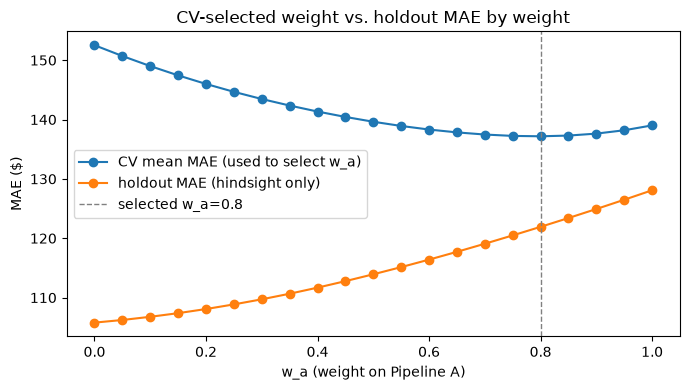

CV curve minimum is at w_a = 0.8 -- pulled toward A by fold 2's weakness for B.
Holdout curve minimum is at w_a = 0.0 -- on this untouched period, pure/near-pure Pipeline B is best.


In [13]:
holdout_w_grid = []
for w in W_GRID:
    blend = w * holdout_pred_a + (1 - w) * holdout_pred_b
    holdout_w_grid.append({"w_a": w, "holdout_MAE": mae(holdout["posted_rate"].to_numpy(), blend)})
holdout_w_df = pd.DataFrame(holdout_w_grid)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid_df.sort_values("w_a")["w_a"], grid_df.sort_values("w_a")["mean_MAE"], marker="o", label="CV mean MAE (used to select w_a)")
ax.plot(holdout_w_df["w_a"], holdout_w_df["holdout_MAE"], marker="o", label="holdout MAE (hindsight only)")
ax.axvline(BEST_W, color="gray", ls="--", lw=1, label=f"selected w_a={BEST_W}")
ax.set_xlabel("w_a (weight on Pipeline A)")
ax.set_ylabel("MAE ($)")
ax.legend()
ax.set_title("CV-selected weight vs. holdout MAE by weight")
plt.tight_layout()
plt.show()

print("CV curve minimum is at w_a =", grid_df.iloc[0]["w_a"], "-- pulled toward A by fold 2's weakness for B.")
print("Holdout curve minimum is at w_a =", holdout_w_df.sort_values("holdout_MAE").iloc[0]["w_a"],
      "-- on this untouched period, pure/near-pure Pipeline B is best.")

## Summary — Pipeline C results

**The ensemble does not help — recommend Pipeline B alone, not the blend.**

CV grid search over the blend weight picked `w_a=0.80` (80% Pipeline A / 20% Pipeline B),
mean CV MAE $137.18 — better than either component alone on CV (A: $139.01, B: $152.52).
That looked like a clean win for ensembling. But on the untouched Sep-Oct holdout, that same
`w_a=0.80` blend scores **MAE $121.93 — worse than Pipeline B alone ($105.79)**, and only
marginally better than Pipeline A alone ($128.09).

| Model | MAE | RMSE | SMAPE | MASE |
|---|---|---|---|---|
| lane-median $/mi x distance (naive) | $194.50 | $658.22 | 7.47% | 1.000 |
| linear log-rate ~ log-dist + equipment | $134.59 | $639.77 | 5.16% | 0.692 |
| Pipeline A alone | $128.09 | $639.59 | 4.73% | 0.659 |
| **Pipeline B alone** | **$105.79** | **$632.51** | **3.85%** | **0.544** |
| Pipeline C (CV-selected ensemble, w_a=0.8) | $121.93 | $637.67 | 4.48% | 0.627 |

**Root cause, confirmed by the post-hoc diagnostic (§ above).** The CV weight search is
dominated by fold 2 (train Jan-Jun, val Jul-Aug), where Pipeline B's ETS Stage 1 does
poorly — flagged already in `Aug_24_Plan.md` as an extrapolation problem specific to that
fold's mid-year-peak horizon, not a general weakness of the two-stage approach. That one
fold's weakness pulls the CV-optimal weight toward Pipeline A (`w_a=0.80`). But the actual
holdout period (Sep-Oct, post-peak) doesn't have that problem, so on the period that
actually matters, Pipeline B needs no help from Pipeline A — the hindsight-only holdout
weight curve bottoms out at `w_a=0.0`, pure Pipeline B.

**This is the KNOWLEDGE.md §5.1 "ensembling is nearly free accuracy" claim failing to hold
here, and it's informative why**: ensembling helps when component errors are independent
noise: here, B's CV weakness is a *diagnosed, fold-specific bias* (a known extrapolation
issue), not noise — blending doesn't cancel out a systematic problem the same way it cancels
random error, and blending toward A just re-introduces A's larger, better-understood error on
the fold where it doesn't need to.

**Recommendation**: ship **Pipeline B alone**. Don't ensemble until fold 2's Stage-1
extrapolation issue is actually fixed (Aug_24_Plan.md next step #1) — at that point, revisit
whether a blend is worth it with a CV signal that's no longer distorted by one bad fold. This
also means the "promote to `src/`" step from Aug_24_Plan.md next step #3 should target
Pipeline B's feature/model code, not attempt to keep both pipelines alive as ensemble inputs.